In [19]:
from safetensors.torch import load_file
import matplotlib.pyplot as plt
import seaborn as sns
device='cpu'
sns.set_theme()

In [ ]:
num_epochs = 2
state_fns = [f'../checkpoints/steering-save-projector/checkpoint-{468 * num}/adapter_model.safetensors' for num in range(1, num_epochs+1)]
projector_weights = []
for state in state_fns:
    state_dict = load_file(state)
    projector_weights.append(state_dict['base_model.model.projector.weight'])
diff_norms = [(projector_weights[i+1] - projector_weights[i]).norm(p='fro').item() for i in range(len(projector_weights)-1)]

Text(0.5, 1.0, 'Convergence of projection matrix during training')

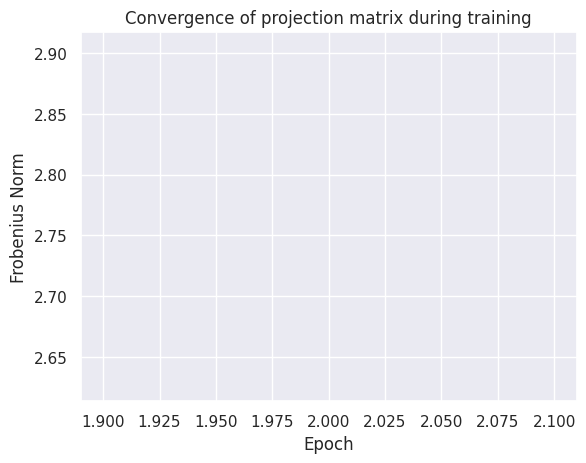

In [41]:
plt.plot(range(2, num_epochs+1), diff_norms)
plt.xlabel('Epoch')
plt.ylabel('Frobenius Norm')
plt.title('Convergence of projection matrix during training')